### This project covers some data analysis on a real data set

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data_set = pd.read_csv("IPL.csv")
data_set.head(5)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### Data Preprocessing

In [13]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [10]:
data_set.shape
print(f'Rows: {data_set.shape[0]} columns: {data_set.shape[1]}')

data_set.isnull().sum()

Rows: 74 columns: 20


match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

### Data Visualising and extracting

In [14]:
data_set.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


<Axes: ylabel='match_winner'>

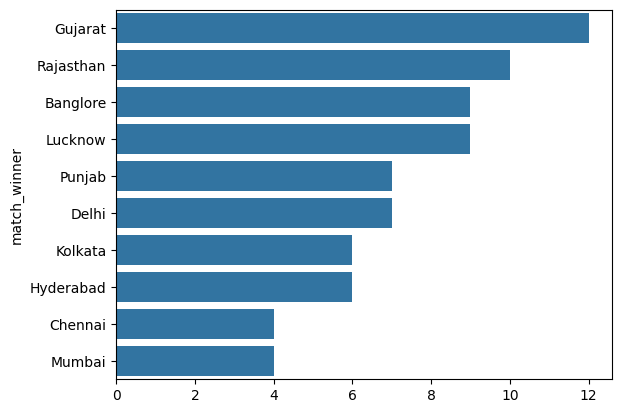

In [21]:
# Team Who Win most matches

match_won = data_set['match_winner'].value_counts()
sns.barplot(y=match_won.index, x=match_won.values)

<Axes: xlabel='toss_decision', ylabel='count'>

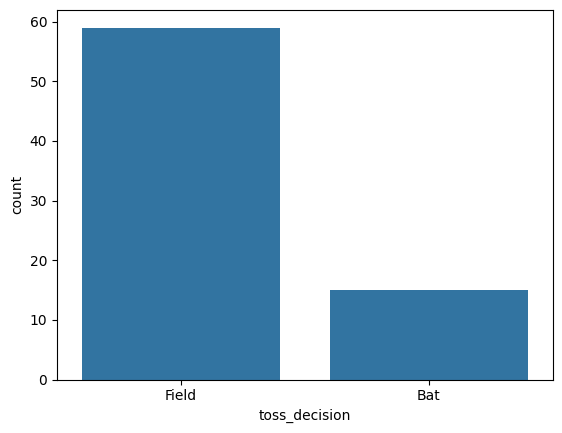

In [30]:
# Result of Toss 
sns.countplot(x = data_set['toss_decision'])

In [35]:
# Toss winner vs Match winner
winner = data_set[data_set['toss_winner'] == data_set['match_winner']].count()['match_id']
percentage = ( winner * 100 ) / data_set.shape[0] 
print(f"the percentage the toss winner is the match winner is {percentage.round(2)}")

the percentage the toss winner is the match winner is 48.65


<Axes: xlabel='won_by'>

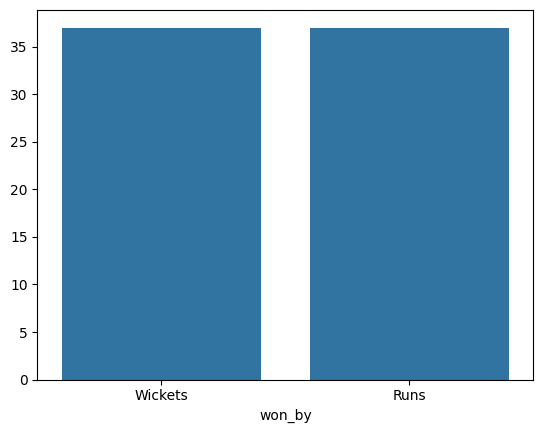

In [39]:
# Match win Condition
condition = data_set['won_by'].value_counts()
sns.barplot(x= condition.index, y=condition.values)

C:\Users\HP\AppData\Local\Temp\ipykernel_9040\2657566756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=MOM.values, y=MOM.index, palette='rainbow')


<Axes: ylabel='player_of_the_match'>

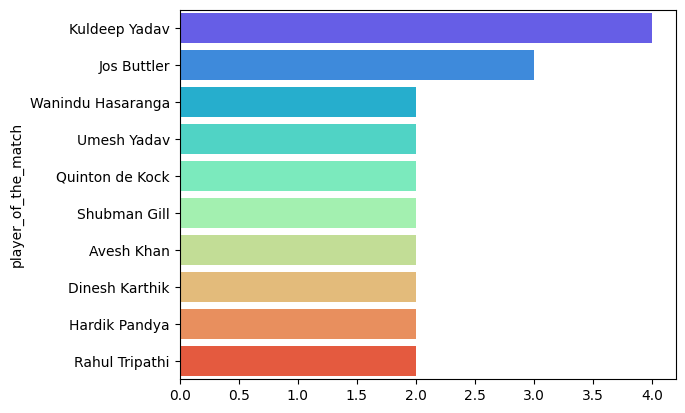

In [46]:
# Most Player of the matches
MOM = data_set['player_of_the_match'].value_counts().head(10)
sns.barplot(x=MOM.values, y=MOM.index, palette='rainbow')

In [51]:
# top 2 Scorers 
data_set.groupby(data_set['top_scorer']).sum()['highscore'].sort_values(ascending=False).head(2)

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

In [52]:
# Top 10 Wicket Taker
data_set.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


<Axes: ylabel='best_bowling'>

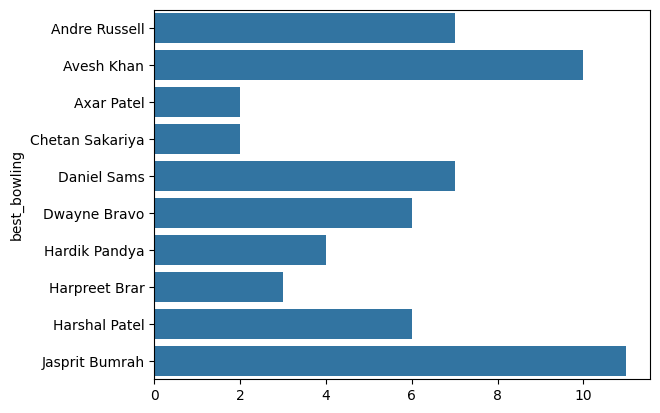

In [68]:
# TOP 10 Bowlers

data_set['wickets'] = data_set['best_bowling_figure'].apply(lambda x: x.split('--')[0])
data_set['wickets'] = data_set['wickets'].astype(int)
top_wicket_takers = data_set.groupby('best_bowling')['wickets'].sum().head(10)

sns.barplot(x=top_wicket_takers.values, y=top_wicket_takers.index)

C:\Users\HP\AppData\Local\Temp\ipykernel_9040\3494721774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_set['venue'], palette='rainbow')


<Axes: xlabel='count', ylabel='venue'>

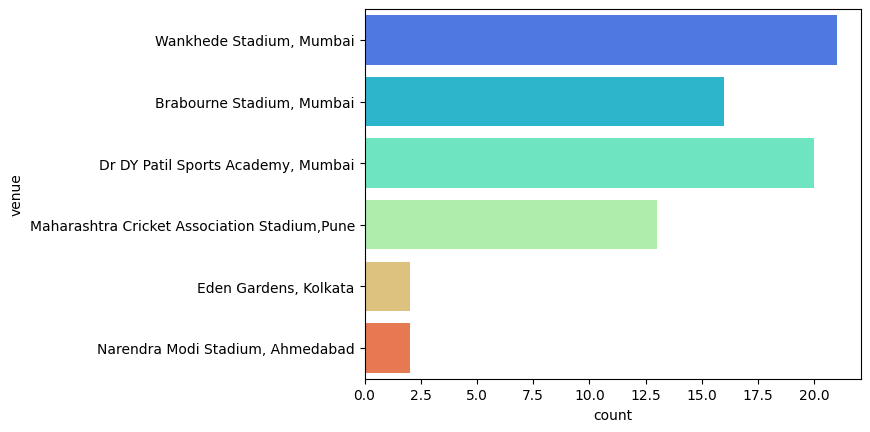

In [73]:
#  Most matches played at a venue 
sns.countplot(y=data_set['venue'], palette='rainbow')

In [78]:
# who won by largest run margins
data_set[data_set['won_by'] == 'Runs'].sort_values(by='margin', ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


In [86]:
# Higest score
data_set[data_set['highscore'] == data_set['highscore'].max()][['top_scorer','highscore']]


,top_scorer,highscore
65,Quinton de Kock,140
